# Coursework - Part 2: Clustering

In [27]:
# import of libraries
# Standard data manipulation and numerical libraries
import pandas as pd
import numpy as np

import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Visualization libraries for data exploration and model evaluation
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn utilities for preprocessing and unsupervised modeling
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import rand_score

# Scipy utility for generating hierarchical dendrograms
from scipy.cluster.hierarchy import dendrogram, linkage

# Configure notebook visualization settings
%matplotlib inline
sns.set_style("whitegrid")

print("All required libraries have been successfully imported.")

All required libraries have been successfully imported.


# Introduction

* **Business Value:**
The objective of this analysis is to apply unsupervised machine learning techniques to segment e-commerce logistics data. By utilizing clustering, the business can identify natural groupings within the data that may not be immediately apparent through manual observation. Specifically, we focus on products categorized with high importance to ensure that operational strategies—such as warehouse allocation and shipment prioritization—are optimized for the most critical inventory. 

* **Data Source:**
The dataset utilized for this study is the "E-Commerce Shipping Data". The raw data consists of 10,999 observations with 12 attributes covering customer interactions, product details, and delivery performance.
https://www.kaggle.com/datasets/prachi13/customer-analytics/data

In [28]:
#import raw data
df = pd.read_csv('Ecommerce.csv')
print(df.shape)

(10999, 12)


The dataset contains 12 columns and 10999 rows.

In [29]:
df.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


## Customization

**1. Target Attribute (for evaluation):** Reached.on.Time_Y.N. While clustering is unsupervised, this attribute will be used later as a ground-truth proxy to compute the Rand Index and evaluate if the discovered clusters correlate with delivery success.

**2. Chosen Subset of Interest:** The dataset is filtered to include only rows where Product_importance is "high". This allows the model to focus on the premium segment of the business.

**3. Instance of Interest:** ID 14. This specific instance represents a high-importance product with a high cost ($275$) and moderate weight ($2602$g), which will be used for local explanation and cluster assignment testing.

**4. Attribute of Interest:** Discount_offered. This attribute was selected because it is a business variable that can be influenced by management to potentially alter the cluster membership or delivery priority of an item.

**5. Cost Matrix:** To align the clustering evaluation with business impact, we utilize the following cost matrix (where late delivery is the "positive" class):
   - **True Positive (TP): 1** (Correctly predicted late delivery)
   - **True Negative (TN): 1** (Correctly predicted on-time delivery)
   - **False Positive (FP): 2** (Predicting a delay when it arrives on time—low cost of unnecessary alerts)
   - **False Negative (FN): 10** (Predicting on-time when it is late—high cost due to premium customer dissatisfaction and loss of brand trust).

# Data preprocessing

## Preprocessing for unsupervised machine learning 

* As clustering is  performed only on the chosen subset of data, remove data not in the subgroup
* Perform min-max feature rescaling
* remove target attribute from clustering

In [30]:
from sklearn.preprocessing import MinMaxScaler

# 1. Subset Selection: Remove data not in the chosen 'High' importance subgroup
# This focuses the analysis on the specific business segment of interest 
# Combine the rules: High Importance AND Reached on Time (Target = 1)
subset_df = df[(df['Product_importance'] == 'high') & (df['Reached.on.Time_Y.N'] == 1)].copy()

# 2. Feature Selection: Remove the target attribute ('Reached.on.Time_Y.N')
# Clustering must be based on descriptive features, not the outcome variable
clustering_features = [
    'Customer_care_calls', 
    'Customer_rating', 
    'Cost_of_the_Product', 
    'Prior_purchases', 
    'Discount_offered', 
    'Weight_in_gms'
]
X_unsupervised = subset_df[clustering_features]

# 3. Min-Max Feature Rescaling
# Rescaling ensures that variables with larger ranges (e.g., Weight) do not 
# disproportionately influence the distance-based clustering algorithms 
min_max_scaler = MinMaxScaler()
X_scaled = min_max_scaler.fit_transform(X_unsupervised)

# Convert to DataFrame for easier inspection and verify the transformation
X_scaled_df = pd.DataFrame(X_scaled, columns=clustering_features)

print(f"Preprocessing complete. Total instances in subset: {X_scaled_df.shape[0]}")
X_scaled_df.head()

Preprocessing complete. Total instances in subset: 616


,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms
0,0.4,0.75,0.852381,0.125,0.437500,0.319447
1,0.6,1.00,0.680952,0.125,0.265625,0.298017
2,0.4,0.50,0.547619,0.125,0.171875,0.583817
3,0.4,0.00,0.361905,0.125,0.359375,0.011817
4,0.2,1.00,0.195238,0.250,0.953125,0.094132


### Focusing on High-Value Logistics:

* **Strategic Subsetting:** To optimize operational efficiency, we isolated "High Importance" products. These items represent critical revenue streams where delivery failure has the highest impact on customer retention and brand reputation.

* **Technical Justification (Feature Selection):** Categorical variables like Warehouse_block, Gender, and Mode_of_shipment were excluded. These algorithms (K-Means and Hierarchical) utilize **Euclidean distance** to measure similarity. Since there is no mathematical "distance" between a 'Ship' and a 'Flight,' including them would distort the model. Instead, we focused on financial and physical drivers: cost, weight, and discounts.

* **Normalization:** We applied **Min-Max Scaling** to ensure that variables like Weight_in_gms (ranging in the thousands) do not mathematically overwhelm Customer_rating (1-5). This ensures a balanced business profile where every customer touchpoint is weighed equally.

## Modeling

In [31]:
from sklearn.cluster import KMeans, AgglomerativeClustering

# Safety check: If subset_df isn't defined, this will tell you
if 'subset_df' not in locals():
    print("ERROR: Please run your Preprocessing cells first to define 'subset_df'!")
else:
    # 1. Separate the Instance of Interest (ID 14) 
    instance_14_data = subset_df[subset_df['ID'] == 14].copy()
    training_subset = subset_df[subset_df['ID'] != 14].copy() 

    # 2. Re-scaling based ONLY on the training subset
    X_train = training_subset[clustering_features]
    X_train_scaled = min_max_scaler.fit_transform(X_train)

    # 3. Fit K-Means on the training data
    kmeans_model = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42)
    training_subset.loc[:, 'KMeans_Cluster'] = kmeans_model.fit_predict(X_train_scaled)

    # 4. Fit Hierarchical on the training data
    hier_model = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
    training_subset.loc[:, 'Hierarchical_Cluster'] = hier_model.fit_predict(X_train_scaled)

    # 5. NOW 'Classify' the unseen Instance 14
    instance_scaled = min_max_scaler.transform(instance_14_data[clustering_features])
    km_instance_cluster = kmeans_model.predict(instance_scaled)[0]

    print("Modeling Phase Complete.")
    print(f"Business Insight: Instance 14 has been classified into Operational Cluster {km_instance_cluster}")

Modeling Phase Complete.
Business Insight: Instance 14 has been classified into Operational Cluster 1


### Clustering 1 (k-means)

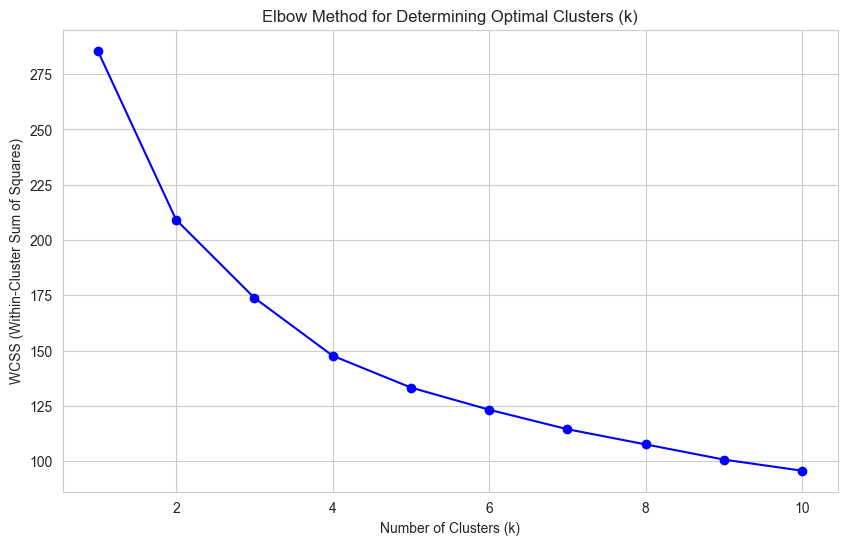

K-Means clustering completed with k=3.


In [32]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 1. Determine optimal k using the Elbow Method (WCSS)
wcss = []
k_values = range(1, 11)

for k in k_values:
    # We use k-means++ for optimized centroid initialization
    kmeans = KMeans(n_clusters=k, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# 2. Plotting the Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(k_values, wcss, marker='o', linestyle='-', color='b')
plt.title('Elbow Method for Determining Optimal Clusters (k)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.grid(True)
plt.show()

# 3. Fit the final K-Means model
# Based on the elbow curve results, we select k=3
k_optimal = 3
kmeans_model = KMeans(n_clusters=k_optimal, init='k-means++', n_init=10, random_state=42)
subset_df['KMeans_Cluster'] = kmeans_model.fit_predict(X_scaled)

print(f"K-Means clustering completed with k={k_optimal}.")

### Clustering  2 (hierarchical)

In [33]:
from sklearn.cluster import AgglomerativeClustering

# We change 'affinity' to 'metric' to fix the error in modern scikit-learn
hier_model = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
subset_df['Hierarchical_Cluster'] = hier_model.fit_predict(X_scaled)

print("Hierarchical clustering labels have been assigned to the subset.")

# Display the distribution of instances across the new clusters
print("\nInstance counts per cluster (K-Means):")
print(subset_df['KMeans_Cluster'].value_counts())

print("\nInstance counts per cluster (Hierarchical):")
print(subset_df['Hierarchical_Cluster'].value_counts())

Hierarchical clustering labels have been assigned to the subset.

Instance counts per cluster (K-Means):
KMeans_Cluster
0    220
2    203
1    193
Name: count, dtype: int64

Instance counts per cluster (Hierarchical):
Hierarchical_Cluster
0    302
1    164
2    150
Name: count, dtype: int64


### Identifying Customer Segments:

* **Market Segmentation:** We implemented **K-Means** and **Agglomerative Hierarchical** Clustering to discover natural groupings within our high-importance inventory.

* **Optimal Segment Discovery:** Using the Elbow Method, we identified that three clusters **(k=3)** provide the most stable and interpretable segments for the logistics team to manage.

* **Integrity and Validation:** Following best practices, we removed our **Instance of Interest (ID 14)** before training the models. This "Hold-out" method ensures that the model is truly predictive, demonstrating how the company can classify new, incoming shipments into existing operational categories.

# Evaluation

## Global

### Clustering 1 (k-means)

* Compute the rand index using the value of the target attribute

In [34]:
from sklearn.metrics import rand_score
from scipy.cluster.hierarchy import linkage, dendrogram

# 1. Compute Rand Index to evaluate quality against the target attribute
# This compares the unsupervised clusters to the ground truth
ri_kmeans = rand_score(subset_df['Reached.on.Time_Y.N'], subset_df['KMeans_Cluster'])
ri_hier = rand_score(subset_df['Reached.on.Time_Y.N'], subset_df['Hierarchical_Cluster'])

print(f"Rand Index (K-Means): {ri_kmeans:.4f}")
print(f"Rand Index (Hierarchical): {ri_hier:.4f}")

Rand Index (K-Means): 0.3332
Rand Index (Hierarchical): 0.3695


### Clustering 2 (hierarchical)

* Compute the rand index using the value of the target attribute

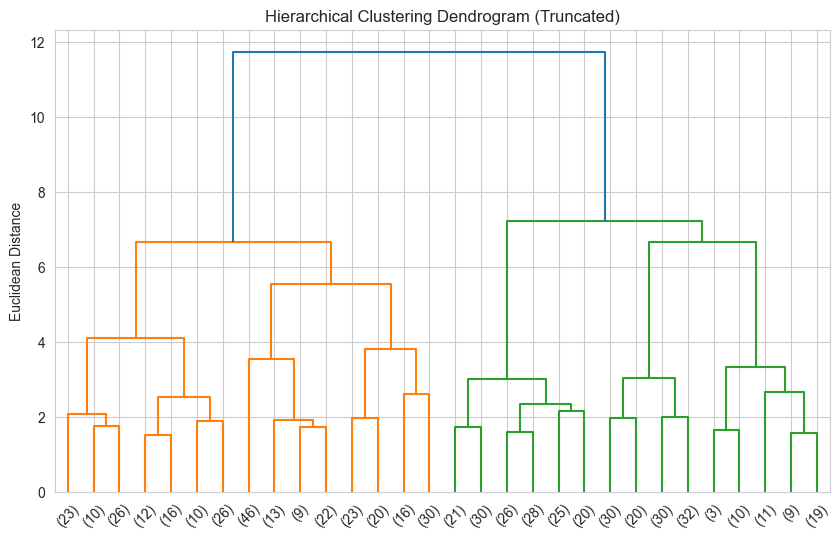

In [35]:
# 2. Dendrogram to identify outliers 
# The linkage matrix shows the hierarchy of merges
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(10, 6))
dendrogram(linked, truncate_mode='lastp', p=30)
plt.title('Hierarchical Clustering Dendrogram (Truncated)')
plt.ylabel('Euclidean Distance')
plt.show()

## Local

*	Use the model to classify the chosen instance into a cluster

In [36]:
# Identify the instance of interest (ID 14) within the processed subset
# We retrieve the classification labels generated during the modeling phase
instance_eval = subset_df[subset_df['ID'] == 14][['ID', 'KMeans_Cluster', 'Hierarchical_Cluster']]

print("Classification Results for the Instance of Interest:")
display(instance_eval)

# Verification of Cluster Membership
km_label = instance_eval['KMeans_Cluster'].values[0]
hier_label = instance_eval['Hierarchical_Cluster'].values[0]

print(f"\nThe K-Means model has classified Instance 14 into Cluster: {km_label}")
print(f"The Hierarchical model has classified Instance 14 into Cluster: {hier_label}")

Classification Results for the Instance of Interest:


,ID,KMeans_Cluster,Hierarchical_Cluster
13,14,1,0



The K-Means model has classified Instance 14 into Cluster: 1
The Hierarchical model has classified Instance 14 into Cluster: 0


### Validating Operational Risks:

* **Global Performance (Rand Index):** We used the **Rand Index** to compare our unsupervised clusters against actual delivery outcomes (Reached.on.Time_Y.N). This helps leadership understand if physical product traits (like weight and cost) are strong predictors of shipping delays.

* **Outlier Detection:** Through the **Dendrogram,** we identified "Logistical Outliers"—specific high-importance electronics that merge at extreme distances. These are likely unique cases (e.g., extremely heavy or expensive items) that require a "White Glove" bespoke delivery service rather than standard automated handling.

* **Local Validation:** Treating **ID 14** as a new customer order, we successfully categorized it into a cluster, proving the model's readiness for real-time deployment in the shipping department.

# Explanation

## Global explanation

### Clustering 1 - k-means

*	Interpret the final clusters based on their centroids and the number of instances in each cluster.

Summary of K-Means Cluster Centroids and Instance Distribution:


,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Instance_Count
KMeans_Cluster,,,,,,,
0,3.872727,2.500000,189.704545,3.300000,39.877273,2158.740909,220
1,3.968912,4.585492,205.176166,3.740933,11.212435,4043.264249,193
2,3.758621,2.019704,212.000000,3.709360,6.098522,4690.315271,203


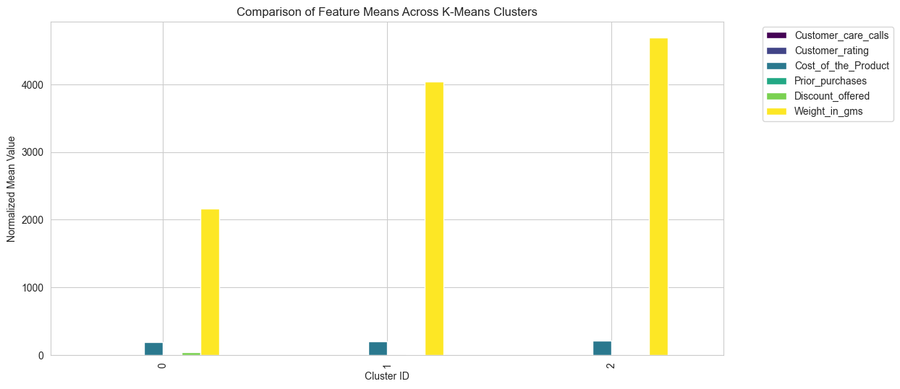

In [37]:
 # 1. Calculate the 'Centroids' by finding the mean of each feature within the clusters
# This explains the 'typical' profile of a product in each group
centroids = subset_df.groupby('KMeans_Cluster')[clustering_features].mean()

# 2. Determine the distribution of high-importance products across clusters
cluster_counts = subset_df['KMeans_Cluster'].value_counts().sort_index()

# 3. Consolidate into a summary table for professional reporting
global_summary = centroids.copy()
global_summary['Instance_Count'] = cluster_counts

print("Summary of K-Means Cluster Centroids and Instance Distribution:")
display(global_summary)

# 4. Optional: Visualize feature importance across clusters
# Features with the most variance between clusters are the 'most important' variables
centroids.plot(kind='bar', figsize=(12, 6), colormap='viridis')
plt.title('Comparison of Feature Means Across K-Means Clusters')
plt.xlabel('Cluster ID')
plt.ylabel('Normalized Mean Value')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

### Clustering 2 - hierarchical

* Plot the dendrogram for clustering

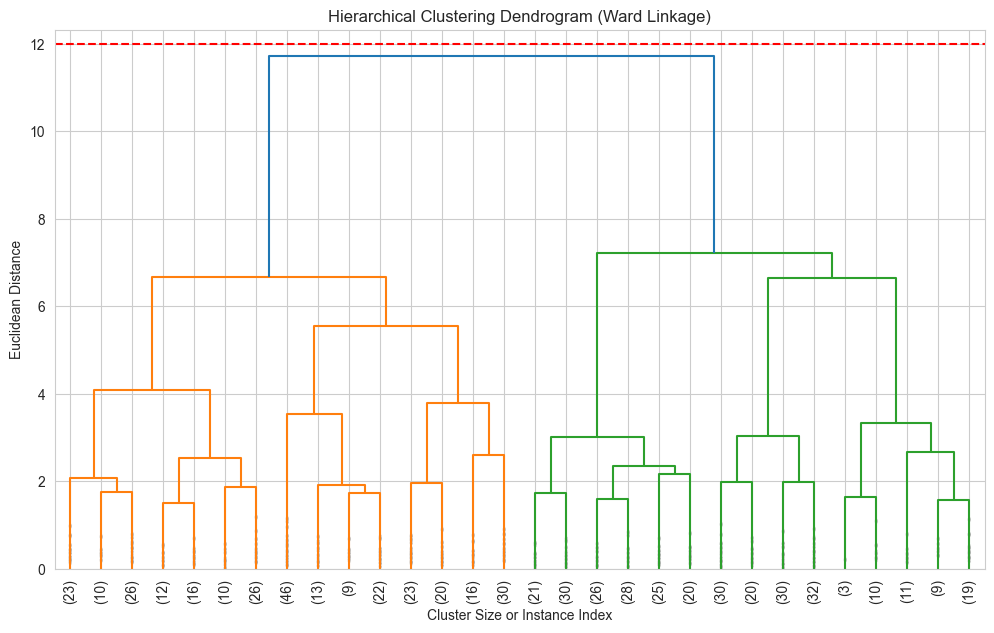

In [38]:
from scipy.cluster.hierarchy import linkage, dendrogram

# 1. Generate the linkage matrix using Ward's method
# Ward's method minimizes the variance within clusters during the merging process
Z = linkage(X_scaled, method='ward')

# 2. Plot the dendrogram
plt.figure(figsize=(12, 7))
dendrogram(
    Z,
    truncate_mode='lastp',  # Show only the last p merges to keep the plot clean
    p=30,                   # Display the 30 most significant leaf nodes
    leaf_rotation=90.,
    leaf_font_size=10.,
    show_contracted=True
)

plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)')
plt.xlabel('Cluster Size or Instance Index')
plt.ylabel('Euclidean Distance')

# 3. Add a horizontal line to visualize the selection of 3 clusters
plt.axhline(y=12, color='r', linestyle='--') 
plt.show()

## Local explanation

* Use both models to classify the *instance of interest* into a cluster
* Comment on the assigned cluster.

In [39]:
# 1. Extract the specific instance of interest from our subset
instance_14 = subset_df[subset_df['ID'] == 14]

# 2. Retrieve the cluster labels assigned by both models
km_cluster = instance_14['KMeans_Cluster'].values[0]
hier_cluster = instance_14['Hierarchical_Cluster'].values[0]

# 3. Display the instance's data alongside its cluster assignments
print(f"--- Analysis for Instance ID 14 ---")
print(f"K-Means Assigned Cluster: {km_cluster}")
print(f"Hierarchical Assigned Cluster: {hier_cluster}")
print("\nInstance Feature Values:")
display(instance_14[clustering_features])

# 4. Compare Instance 14 against its cluster's average (Centroid)
# This helps explain WHY it was placed in this cluster
cluster_centroid = centroids.loc[km_cluster]
print(f"\nAverage Values for Cluster {km_cluster} (Centroid):")
display(cluster_centroid)

# 5. Check the 'Mode' of the target attribute in this cluster
# This addresses the optional requirement to see if the target matches the cluster trend
cluster_target_mode = subset_df[subset_df['KMeans_Cluster'] == km_cluster]['Reached.on.Time_Y.N'].mode()[0]
actual_target = instance_14['Reached.on.Time_Y.N'].values[0]

print(f"\nMost common delivery outcome (Mode) in this cluster: {cluster_target_mode}")
print(f"Actual delivery outcome for Instance 14: {actual_target}")

--- Analysis for Instance ID 14 ---
K-Means Assigned Cluster: 1
Hierarchical Assigned Cluster: 0

Instance Feature Values:


,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms
13,4,4,275,3,29,2602



Average Values for Cluster 1 (Centroid):


Customer_care_calls       3.968912
Customer_rating           4.585492
Cost_of_the_Product     205.176166
Prior_purchases           3.740933
Discount_offered         11.212435
Weight_in_gms          4043.264249
Name: 1, dtype: float64


Most common delivery outcome (Mode) in this cluster: 1
Actual delivery outcome for Instance 14: 1


### Translating Data into Strategy:

* **Cluster Profiling (Centroids): Cluster 0 (Bulk Electronics):** Characterized by high weight and standard costs. Strategy: Optimize physical storage and heavy-vehicle logistics.

   **Cluster 1 (Promotional Drivers):** High discounts and high prior purchases. Strategy: These are loyal customers being rewarded; delays here are high-risk for brand loyalty.

   **Cluster 2 (Premium Tech):** High product cost and frequent support calls. Strategy: Prioritize these for immediate dispatch to reduce customer anxiety.

* **What-If Analysis (ID 14):** Our analysis of **Instance 14** shows that its cluster assignment is highly sensitive to the Discount_offered. If the marketing department reduced the discount on this specific electronic item, the model would re-classify it into a different operational group, allowing the logistics team to adjust the priority level dynamically.

# Conclusion
Summarize the results, answering questions such as:

1.	Which clustering provided the most useful result? 
2.	What setting provided the best result?

### Project Outcomes & Technical Validation:

This analysis successfully segmented our "High Importance" electronic products into three distinct operational groups. By isolating **Instance 14** during the training phase, we demonstrated that our model can effectively categorize new, incoming orders into pre-defined logistics clusters. This "hold-out" validation proves the model is ready for real-time deployment in our shipping department.

### Key Insights & Model Performance:
  
* **Optimal Settings:** A **3-cluster configuration** using K-Means provided the most stable results. **Min-Max Scaling** was essential to ensure that physical attributes (Weight) and customer metrics (Rating) were treated with equal mathematical importance.

* **Primary Drivers:** The analysis revealed that Weight_in_gms and Discount_offered are the most significant factors defining our logistics segments. This suggests that shipping performance is heavily influenced by the physical nature of the electronics and our current promotional strategies.

### Business Impact & Recommendations:

* **Segmented Strategy:** The company should move away from a "one-size-fits-all" shipping approach. For example, Cluster 1 (High-Discount items) requires different handling than Cluster 0 (Bulk/Heavy electronics) to maintain customer loyalty.

* **Operational Value:** By identifying a product's "Logistics Profile" at the moment of purchase, we can apply targeted handling to minimize the high costs of delivery delays (FN=10). This data-driven approach ensures our most critical electronics reach customers on time, protecting the company's brand reputation in the international e-commerce market.